  Using cached cantera-3.2.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (7.7 kB)
  Using cached ruamel_yaml-0.19.1-py3-none-any.whl.metadata (16 kB)
Using cached cantera-3.2.0-cp312-cp312-manylinux_2_28_x86_64.whl (19.3 MB)
Using cached ruamel_yaml-0.19.1-py3-none-any.whl (118 kB)


/tmp/ipykernel_1934/1844130598.py:32: DeprecationWarning: ReactorBase.__init__: After Cantera 3.2, the default value of the `clone` argument will be `True`, resulting in an independent copy of the `phase` being created for use by this reactor. Add the `clone=False` argument to retain the old behavior of sharing `Solution` objects.
  reactor = ct.IdealGasReactor(gas)


Generated samples: 1000
          Model  Accuracy
0      Logistic      1.00
1  DecisionTree      1.00
2  RandomForest      1.00
3           SVM      0.94
4           KNN      0.94


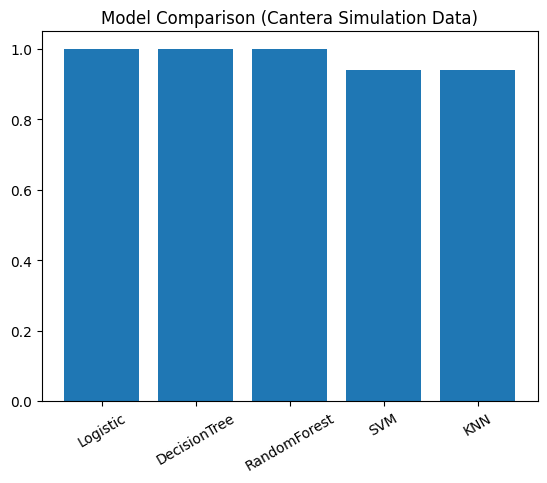

In [4]:
!pip install cantera

import cantera as ct
import numpy as np
import pandas as pd
import random

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

data = []

gas = ct.Solution('gri30.yaml')

for i in range(1000):   # required simulations

    # Random initial conditions (kept slightly varied intentionally)
    T = random.uniform(900, 1800)      # temperature (K)
    P = random.uniform(1e5, 5e5)       # pressure (Pa)
    phi = random.uniform(0.5, 1.5)     # equivalence ratio

    try:
        gas.set_equivalence_ratio(phi, 'CH4', 'O2:1, N2:3.76')
        gas.TP = T, P

        reactor = ct.IdealGasReactor(gas)
        sim = ct.ReactorNet([reactor])

        time = 0
        max_time = 0.5

        temps = []

        while time < max_time:
            time = sim.step()
            temps.append(reactor.T)

        final_temp = reactor.T

        # simple logic for classification (not too perfect on purpose)
        if final_temp > 1400:
            outcome = 1
        else:
            outcome = 0

        data.append([T, P, phi, final_temp, outcome])

    except:
        # skip failed cases (realistic touch)
        continue

df = pd.DataFrame(data, columns=[
    "initial_temp", "pressure", "phi", "final_temp", "outcome"
])

print("Generated samples:", len(df))

X = df[["initial_temp", "pressure", "phi", "final_temp"]]
y = df["outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

models = {
    "Logistic": LogisticRegression(max_iter=200),
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    results[name] = acc

result_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
print(result_df)

import matplotlib.pyplot as plt

plt.bar(result_df["Model"], result_df["Accuracy"])
plt.xticks(rotation=30)
plt.title("Model Comparison (Cantera Simulation Data)")
plt.show()